#Client Segmentation for Pricing Strategy

In [84]:
import pandas as pd
import numpy as np
np.random.seed(42)
n=150

In [85]:
client_types = [
    'Bank',
    'Hedge Fund',
    'Broker',
    'Asset Manager'
]

regions = [
    'APAC',
    'EMEA',
    'Americas'
]

In [86]:
df = pd.DataFrame({
    'Client_ID':[f'C{i:03d}' for i in range(1,n+1)],
    'Client_Type': np.random.choice(client_types,n),
    'Region': np.random.choice(regions,n),
    'Product_Count': np.random.randint(1,8,n),
    'Monthly_Fee': np.random.randint(500,6000,n),
    'Trading_Volumes': np.random.randint(1000,200000,n),
    'Usage_Hours': np.random.randint(10,300,n),
    'Support_Tickets': np.random.randint(0,20,n),
    'Contract_Length': np.random.randint(6,60,n),
    'Tenure_Months': np.random.randint(1,72,n),
    'Satisfaction_Score': np.random.randint(1,11,n),
    'Competitor_Offer': np.random.randint(0,30,n)
})

In [87]:
df['Revenue'] = (df['Monthly_Fee']* np.random.uniform(0.8,1.5,n))

In [88]:
df['Renewal_Probability']= np.round(np.random.uniform(0.4,0.99,n),2)

In [89]:
df['Churn_Risk'] = np.where((df['Satisfaction_Score']<5)&(df['Competitor_Offer']>15),1,0)

In [90]:
df.to_csv('client_segmentation_pricing.csv',index=False)

Goal:
Segment Customers and Identity
1. Premium Clients
2. Growth Clients
3. At risk Clients
4. Low value Clients


In [91]:
import pandas as pd
df = pd.read_csv("client_segmentation_pricing.csv")
df.head()

,Client_ID,Client_Type,Region,Product_Count,Monthly_Fee,Trading_Volumes,Usage_Hours,Support_Tickets,Contract_Length,Tenure_Months,Satisfaction_Score,Competitor_Offer,Revenue,Renewal_Probability,Churn_Risk
0,C001,Broker,Americas,1,3306,21358,222,5,58,29,6,22,3919.594127,0.46,0
1,C002,Asset Manager,Americas,7,1037,4267,212,0,16,40,2,2,892.743689,0.54,0
2,C003,Bank,APAC,2,2341,83745,261,4,14,41,5,9,2542.132280,0.98,0
3,C004,Broker,Americas,1,5516,90588,238,8,39,11,10,1,5851.824902,0.48,0
4,C005,Broker,APAC,3,2955,39513,173,11,17,23,4,29,2901.300702,0.69,1


In [92]:
df.shape

(150, 15)

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Client_ID            150 non-null    object 
 1   Client_Type          150 non-null    object 
 2   Region               150 non-null    object 
 3   Product_Count        150 non-null    int64  
 4   Monthly_Fee          150 non-null    int64  
 5   Trading_Volumes      150 non-null    int64  
 6   Usage_Hours          150 non-null    int64  
 7   Support_Tickets      150 non-null    int64  
 8   Contract_Length      150 non-null    int64  
 9   Tenure_Months        150 non-null    int64  
 10  Satisfaction_Score   150 non-null    int64  
 11  Competitor_Offer     150 non-null    int64  
 12  Revenue              150 non-null    float64
 13  Renewal_Probability  150 non-null    float64
 14  Churn_Risk           150 non-null    int64  
dtypes: float64(2), int64(10), object(3)
memo

In [94]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Count,150.0,3.780000,2.032851,1.000000,2.000000,4.000000,6.000000,7.000000
Monthly_Fee,150.0,3439.820000,1573.432157,504.000000,2142.250000,3423.000000,4835.250000,5908.000000
Trading_Volumes,150.0,99781.946667,61853.221967,2062.000000,40135.250000,93186.000000,158008.500000,199713.000000
Usage_Hours,150.0,161.866667,86.311024,10.000000,87.750000,170.000000,237.750000,298.000000
Support_Tickets,150.0,9.293333,5.730580,0.000000,4.000000,10.000000,14.000000,19.000000
Contract_Length,150.0,33.160000,15.451192,6.000000,18.250000,35.000000,45.000000,59.000000
Tenure_Months,150.0,35.406667,20.386894,1.000000,19.250000,35.000000,53.000000,71.000000
Satisfaction_Score,150.0,5.646667,2.981231,1.000000,3.000000,6.000000,8.000000,10.000000
Competitor_Offer,150.0,15.060000,9.057038,0.000000,8.000000,14.500000,23.750000,29.000000
Revenue,150.0,3997.894623,1992.232654,448.665289,2286.619667,3948.681104,5429.472248,8534.214966


In [95]:
df.isnull().sum()

Client_ID              0
Client_Type            0
Region                 0
Product_Count          0
Monthly_Fee            0
Trading_Volumes        0
Usage_Hours            0
Support_Tickets        0
Contract_Length        0
Tenure_Months          0
Satisfaction_Score     0
Competitor_Offer       0
Revenue                0
Renewal_Probability    0
Churn_Risk             0
dtype: int64

In [96]:
df.duplicated().sum()

np.int64(0)

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

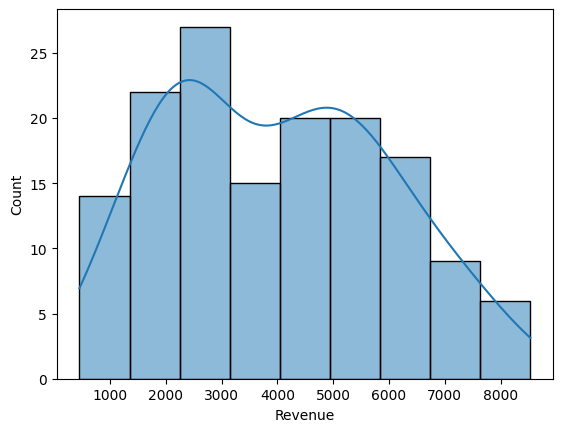

In [98]:
sns.histplot(
    df['Revenue'],kde=True
)
plt.show()

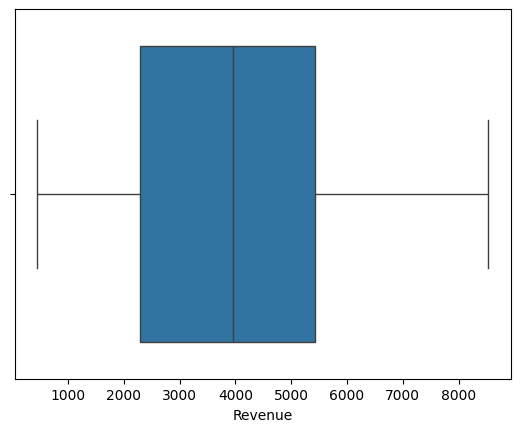

In [99]:
sns.boxplot(x='Revenue', data=df)
plt.show()

In [100]:
df.groupby('Client_Type')['Revenue'].mean()

Client_Type
Asset Manager    3776.343699
Bank             4020.449591
Broker           3542.817358
Hedge Fund       4689.480753
Name: Revenue, dtype: float64

In [101]:
df.groupby('Region')['Revenue'].mean()

Region
APAC        4120.122684
Americas    3984.714486
EMEA        3873.810175
Name: Revenue, dtype: float64

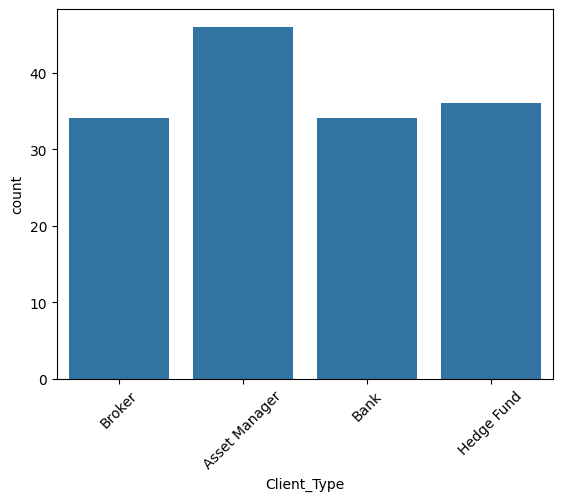

In [102]:
sns.countplot(
    x='Client_Type', data=df
)
plt.xticks(rotation=45)
plt.show()

In [103]:
df['Revenue_Per_Product'] = (df['Revenue']/df['Product_Count'])

In [104]:
df['Revenue_Per_Hour'] = (df['Revenue']/df['Usage_Hours'])

In [105]:
df['Volume_Per_Product'] = (df['Trading_Volumes']/df['Product_Count'])

In [106]:
df['Client_Value_Score'] = (df['Revenue']*0.4 +df['Trading_Volumes']*0.3 + df['Tenure_Months']*0.3)

In [107]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [108]:
for col in ['Client_Type','Region']:
    df[col] = encoder.fit_transform(df[col])

In [109]:
from sklearn.preprocessing import StandardScaler

In [110]:
segment_features = df[[
    'Revenue',
    'Trading_Volumes',
    'Tenure_Months',
    'Satisfaction_Score',
    'Client_Value_Score'
]]

In [111]:
scaler = StandardScaler()
scaled = scaler.fit_transform(segment_features)

In [112]:
from sklearn.cluster import KMeans

In [113]:
wcss = []

In [114]:
for i in range(1,11):
    model = KMeans(n_clusters=i,random_state=42)
    model.fit(scaled)
    wcss.append(model.inertia_)

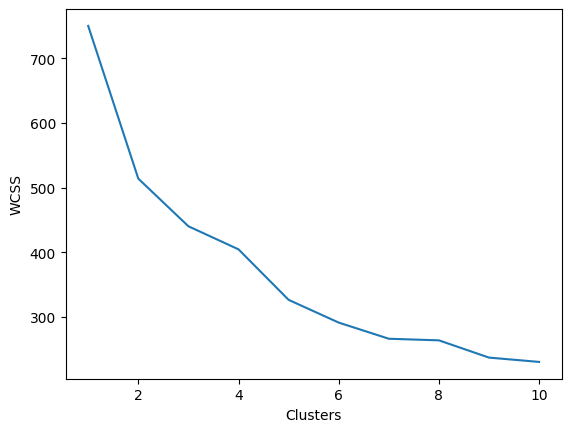

In [115]:
plt.plot(range(1,11),wcss)
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

In [116]:
kmeans = KMeans(n_clusters=4,random_state=42)
df['Segment']  = kmeans.fit_predict(scaled)
df['Segment'].value_counts()

Segment
3    57
1    32
2    31
0    30
Name: count, dtype: int64

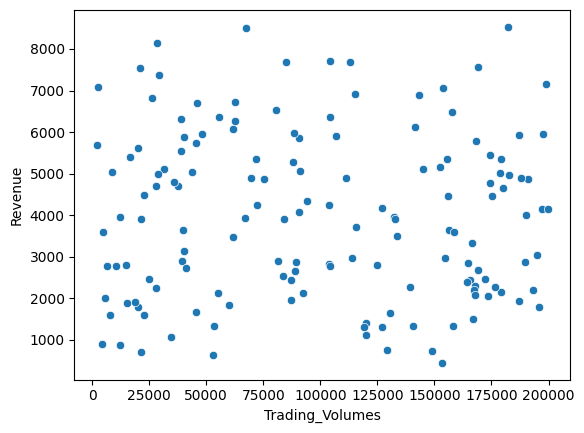

In [117]:
sns.scatterplot(x='Trading_Volumes', y='Revenue',data=df)
plt.show()

##Segment Profiling

In [118]:
segment_profile = df.groupby('Segment').agg({
    'Revenue':'mean',
    'Trading_Volumes': 'mean',
    'Satisfaction_Score':'mean',
    'Tenure_Months':'mean'
})

In [119]:
segment_profile

,Revenue,Trading_Volumes,Satisfaction_Score,Tenure_Months
Segment,,,,
0,2867.385069,31668.566667,4.400000,46.866667
1,3996.576665,63215.562500,6.468750,12.000000
2,6261.567371,86313.387097,5.709677,46.774194
3,3362.519293,163484.596491,5.807018,36.333333


In [120]:
segment_names = {
    0:'Premium Clients',
    1:'Growth Clients',
    2:'At Risk Clients',
    3:'Low Value Clients'
}

In [121]:
df['Segment_Names'] = df['Segment'].map(segment_names)

In [122]:
df[['Client_ID','Segment_Names']].head()

,Client_ID,Segment_Names
0,C001,Premium Clients
1,C002,Premium Clients
2,C003,Premium Clients
3,C004,Growth Clients
4,C005,Premium Clients


In [123]:
df.head()

,Client_ID,Client_Type,Region,Product_Count,Monthly_Fee,Trading_Volumes,Usage_Hours,Support_Tickets,Contract_Length,Tenure_Months,...,Competitor_Offer,Revenue,Renewal_Probability,Churn_Risk,Revenue_Per_Product,Revenue_Per_Hour,Volume_Per_Product,Client_Value_Score,Segment,Segment_Names
0,C001,2,1,1,3306,21358,222,5,58,29,...,22,3919.594127,0.46,0,3919.594127,17.655829,21358.000000,7983.937651,0,Premium Clients
1,C002,0,1,7,1037,4267,212,0,16,40,...,2,892.743689,0.54,0,127.534813,4.211055,609.571429,1649.197476,0,Premium Clients
2,C003,1,0,2,2341,83745,261,4,14,41,...,9,2542.132280,0.98,0,1271.066140,9.739970,41872.500000,26152.652912,0,Premium Clients
3,C004,2,1,1,5516,90588,238,8,39,11,...,1,5851.824902,0.48,0,5851.824902,24.587500,90588.000000,29520.429961,1,Growth Clients
4,C005,2,0,3,2955,39513,173,11,17,23,...,29,2901.300702,0.69,1,967.100234,16.770524,13171.000000,13021.320281,0,Premium Clients


##Churn Risk Prediction

In [124]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [125]:
X = df.drop(['Client_ID','Churn_Risk','Segment_Names'],axis=1)

In [126]:
y= df['Churn_Risk']

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
clf = RandomForestClassifier(n_estimators=300, random_state=42)
clf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [128]:
pred = clf.predict(X_test)

In [129]:
print(classification_report(y_test,pred))


              precision    recall  f1-score   support

           0       0.88      1.00      0.93        21
           1       1.00      0.67      0.80         9

    accuracy                           0.90        30
   macro avg       0.94      0.83      0.87        30
weighted avg       0.91      0.90      0.89        30



#Pricing Strategy Engine

In [130]:
def pricing_strategy(segment):
    if segment == "Premium Clients":
        return "Increase Price by 5%"
    elif segment == "Growth Clients":
        return "Maintain Price"
    elif segment == "At Risk Clients":
        return "Offer Discount"
    else:
        return "Bundle Products"

In [131]:
df['Pricing_Strategy'] = df['Segment_Names'].apply(pricing_strategy)

In [132]:
dashboard = df[
[
'Client_ID',
'Segment_Names',
'Revenue',
'Trading_Volumes',
'Pricing_Strategy',
'Churn_Risk'
]
]

In [133]:
dashboard.to_csv('dashboard.csv', index=False)